##Read Images

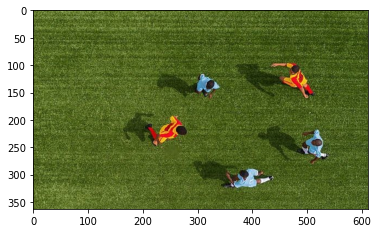

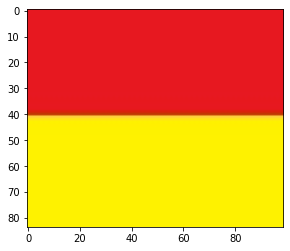

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#read image
template = cv2.imread('/content/Color-image.jpg')
main = cv2.imread('/content/Player-image.jpg')

main = cv2.cvtColor(main, cv2.COLOR_RGB2BGR)
template = cv2.cvtColor(template, cv2.COLOR_RGB2BGR)

plt.imshow(main)
plt.figure()
plt.imshow(template)

##Edge Detection (Complete This section)

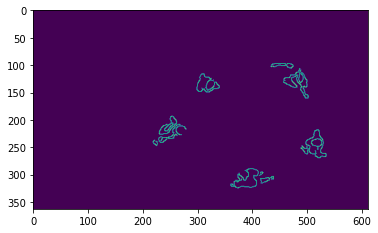

In [ ]:
#write edge detection here
gray = cv2.cvtColor(main, cv2.COLOR_BGR2GRAY)
#...
#...
plt.imshow(edges)

##Object detection

5 objects were found in this image.


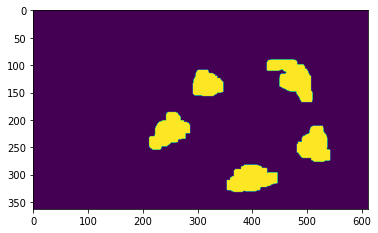

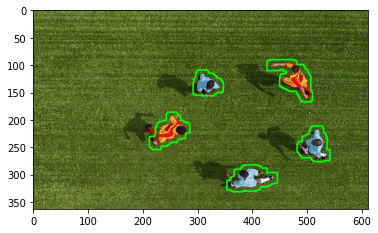

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

# apply the dilation operation to the edged image
dilate = cv2.dilate(edges, kernel, iterations=1)

# find the contours in the dilated image
contours, _ = cv2.findContours(dilate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
image_copy = main.copy()
# draw the contours on a copy of the original image
cv2.drawContours(image_copy, contours, -1, (0, 255, 0), 2)
print(len(contours), "objects were found in this image.")

plt.imshow(dilate)
plt.figure()
plt.imshow(image_copy)

In [ ]:
contours_poly = [None]*len(contours)
boundRect = [None]*len(contours)
centers = [None]*len(contours)
radius = [None]*len(contours)
for i, c in enumerate(contours):
    contours_poly[i] = cv2.approxPolyDP(c, 3, True)
    boundRect[i] = cv2.boundingRect(contours_poly[i])
    centers[i], radius[i] = cv2.minEnclosingCircle(contours_poly[i])

##Similarity function (Complete This section)

In [ ]:
def similarity(ref,template):

  #...
  #...

  return score

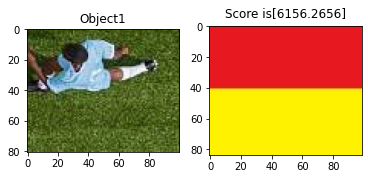

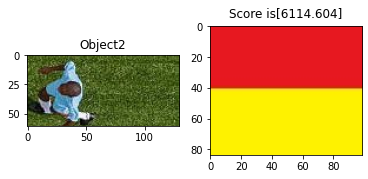

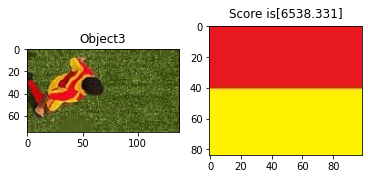

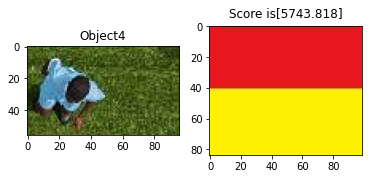

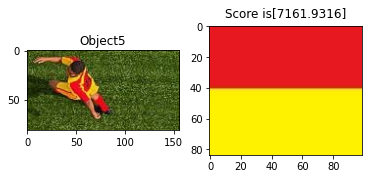

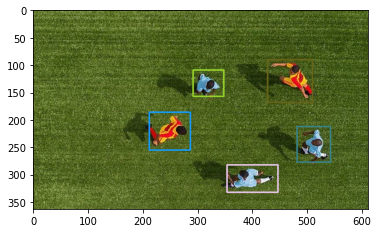

In [ ]:
import random as rng
drawing = main.copy()
score=0
for i in range(len(contours)):
  color = (rng.randint(0,256), rng.randint(0,256), rng.randint(0,256))
  cv2.rectangle(drawing, (int(boundRect[i][0]), int(boundRect[i][1])),(int(boundRect[i][0]+boundRect[i][2]), int(boundRect[i][1]+boundRect[i][3])), color, 2)
  ref=main[int(boundRect[i][1]):int(boundRect[i][1])+int(boundRect[i][2]), int(boundRect[i][0]):(int(boundRect[i][0])+2*int(boundRect[i][3])) ,:]

  plt.subplot(1, 2, 1)
  plt.imshow(ref)
  plt.title("Object"+str(i+1))
  
  score = similarity(ref,template)

  plt.subplot(1, 2, 2)
  plt.imshow(template)
  plt.title('Score is' + str(score),va="bottom")
  plt.show()
  plt.figure()

  
plt.imshow(drawing)